# Species–Area Relationships of Amphibians and Reptiles in Eastern Tennessee

This notebook reproduces the species–area relationship (SAR) analysis from Jessee et al. (2022), which examined herpetofaunal richness across a nested series of land areas in eastern Tennessee — from Steele Creek Park (9.3 km²) to all of eastern Tennessee (37,438 km²). Using the classical power model *S = CA^z*, separate regressions are fit for total herpetofauna, amphibians, and reptiles, and the resulting models are tested against independent site data including Great Smoky Mountains National Park.

> Jessee, M. R., McMeen, J. W., Klukowski, M., & Hamed, M. K. (2022). Species–area relationships of amphibians and reptiles in eastern Tennessee. *Journal of North American Herpetology*, 2022(1), 42–48.

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

file = "data/herpetofauna.csv"

if not os.path.exists(file):
    raise FileNotFoundError(f"Data file not found: {file}. Ensure it exists relative to the notebook working directory.")

## Load and Explore the Data

Create a DataFrame from herpetofauna.csv. This data represents a nested sample of increasingly larger land areas: Steele Creek Park, Sullivan County, the 5-county area of northeastern Tennessee, and all of eastern Tennessee.

In [48]:
raw = pd.read_csv(file)
df = raw.copy()

print(file)
display(df)

print("Statistics")
df.describe()

data/herpetofauna.csv


,Locality,Area,TotalHerpetofauna,Amphibians,Reptiles
0,Steele Creek Park,9.3,41,20,21
1,Sullivan County,1114.0,59,38,21
2,Northeastern Tennessee,4137.0,68,44,24
3,Eastern Tennessee,37438.0,113,69,44


Statistics


,Area,TotalHerpetofauna,Amphibians,Reptiles
count,4.000000,4.000000,4.000000,4.000000
mean,10674.575000,70.250000,42.750000,27.500000
std,17927.385846,30.630867,20.254629,11.090537
min,9.300000,41.000000,20.000000,21.000000
25%,837.825000,54.500000,33.500000,21.000000
50%,2625.500000,63.500000,41.000000,22.500000
75%,12462.250000,79.250000,50.250000,29.000000
max,37438.000000,113.000000,69.000000,44.000000


## Plotting

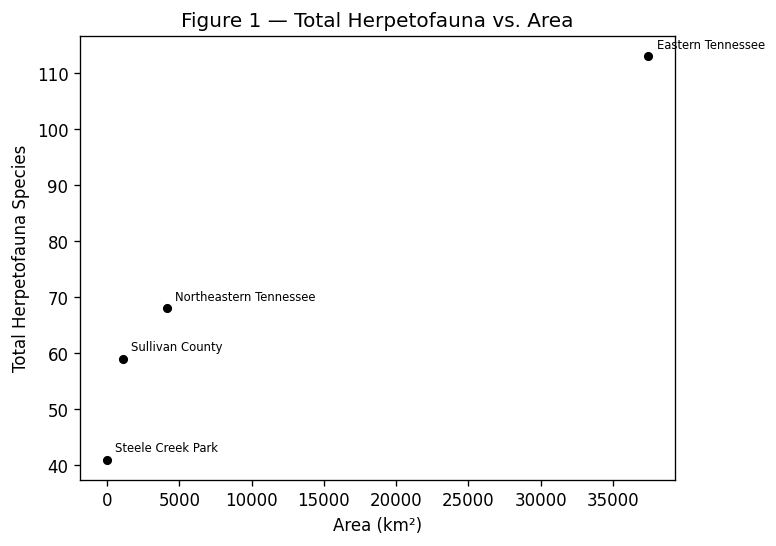

In [49]:
# plot the scatter plot using pyplot and the Pandas builtin wrapper for pyplot
df.plot.scatter(x='Area', y='TotalHerpetofauna', color='black')
plt.xlabel('Area (km²)')
plt.ylabel('Total Herpetofauna Species')
plt.title('Figure 1 — Total Herpetofauna vs. Area')

# Annotate each point with locality name
for _, row in df.iterrows():
    plt.annotate(row['Locality'], (row['Area'], row['TotalHerpetofauna']),
                 textcoords="offset points", xytext=(5, 5), fontsize=7)
plt.show()

## Log Transformation

To model the SAR, species richness and geographical area samples were logarithmically (log10) transformed, and a regression analysis was performed. The species–area curve was flattened by taking the log10 values for both species and land area and plotted as a linear regression. The regression equation from Figure 2 in the publication for total herpetofauna is $y = 0.1137x + 1.4704$. 

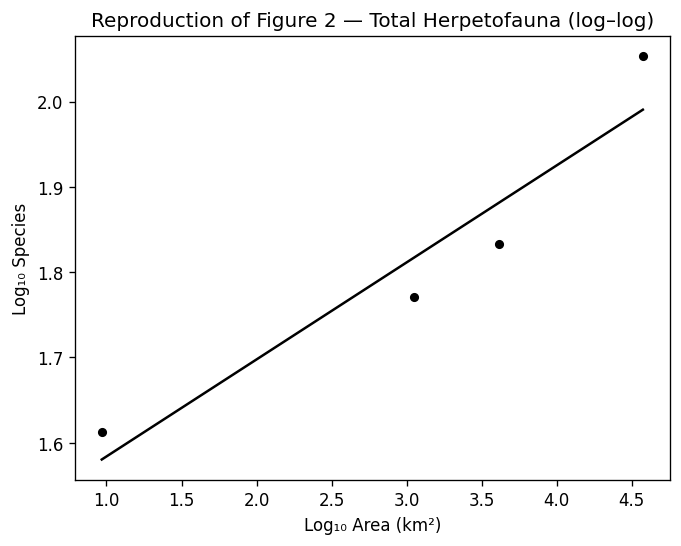

Total Herpetofauna regression: y = 0.1138x + 1.4701
  R² = 0.9048,  Adj. R² = 0.8573,  P = 0.0488


In [50]:
# create and populate log10 columns based on existing columns
df['Log10Area'] = np.log10(df['Area'])
df['Log10TotalHerpetofauna'] = np.log10(df['TotalHerpetofauna'])

# fit a linear regression using scipy.stats for slope, intercept, R², and p-value
reg_herps = stats.linregress(df['Log10Area'], df['Log10TotalHerpetofauna'])
m_herps, b_herps = reg_herps.slope, reg_herps.intercept

# add the series values and the regression line to the scatter plot
fig, ax = plt.subplots()
df.plot.scatter(x='Log10Area', y='Log10TotalHerpetofauna', color='black', ax=ax)
plt.plot(df['Log10Area'], m_herps * df['Log10Area'] + b_herps, color='black')
plt.xlabel('Log₁₀ Area (km²)')
plt.ylabel('Log₁₀ Species')
plt.title('Reproduction of Figure 2 — Total Herpetofauna (log–log)')
plt.show()

# Print the model and statistics
print(f'Total Herpetofauna regression: y = {m_herps:.4f}x + {b_herps:.4f}')
print(f'  R² = {reg_herps.rvalue**2:.4f},  Adj. R² = {1 - (1 - reg_herps.rvalue**2) * (len(df) - 1) / (len(df) - 2):.4f},  P = {reg_herps.pvalue:.4f}')

## Amphibians vs. Reptiles

The study also calculated separate regression models for amphibians and reptiles. According to Figure 2 in the publication:
- **Amphibians:** $y = 0.1449x + 1.1488$ (Adj. $R^2 = 0.98$, $P = 0.006$)
- **Reptiles:** $y = 0.0747x + 1.189$ (Adj. $R^2 = 0.33$, $P = 0.257$)

The amphibian model shows a much stronger fit than the reptile model, suggesting that amphibian richness adheres more closely to the species–area relationship than reptiles in this region. Let's plot all three groups together.

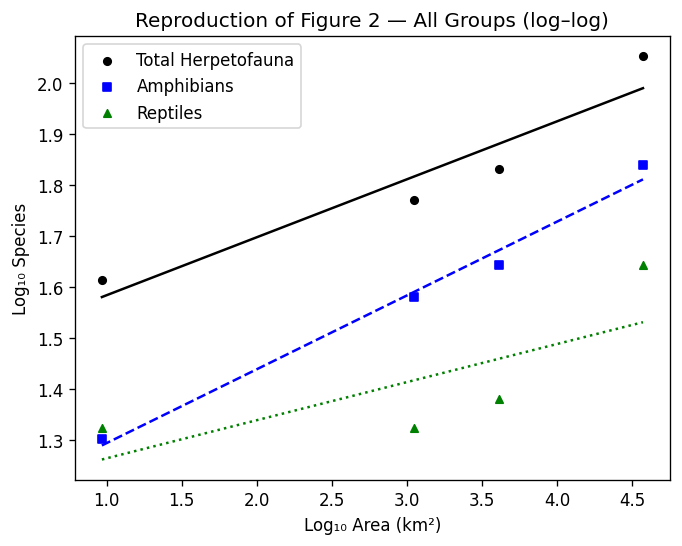

Total Herpetofauna: y = 0.1138x + 1.4701  |  R² = 0.9048,  Adj. R² = 0.86,  P = 0.0488
Amphibians: y = 0.1449x + 1.1485  |  R² = 0.9874,  Adj. R² = 0.98,  P = 0.0063
Reptiles: y = 0.0748x + 1.1888  |  R² = 0.5527,  Adj. R² = 0.33,  P = 0.2565


In [51]:
# create and populate log10 columns for amphibians and reptiles
df['Log10Amphibians'] = np.log10(df['Amphibians'])
df['Log10Reptiles'] = np.log10(df['Reptiles'])

# fit regressions with full statistics
reg_amphibians = stats.linregress(df['Log10Area'], df['Log10Amphibians'])
reg_reptiles = stats.linregress(df['Log10Area'], df['Log10Reptiles'])
m_amphibians, b_amphibians = reg_amphibians.slope, reg_amphibians.intercept
m_reptiles, b_reptiles = reg_reptiles.slope, reg_reptiles.intercept

# adding the regression line to the scatter plot
fig, ax = plt.subplots()
df.plot.scatter(x='Log10Area', y='Log10TotalHerpetofauna', color='black', label='Total Herpetofauna', ax=ax)
df.plot.scatter(x='Log10Area', y='Log10Amphibians', color='blue', marker='s', label='Amphibians', ax=ax)
df.plot.scatter(x='Log10Area', y='Log10Reptiles', color='green', marker='^', label='Reptiles', ax=ax)
plt.plot(df['Log10Area'], m_herps * df['Log10Area'] + b_herps, color='black')
plt.plot(df['Log10Area'], m_amphibians * df['Log10Area'] + b_amphibians, color='blue', linestyle='--')
plt.plot(df['Log10Area'], m_reptiles * df['Log10Area'] + b_reptiles, color='green', linestyle=':')
plt.xlabel('Log₁₀ Area (km²)')
plt.ylabel('Log₁₀ Species')
plt.title('Reproduction of Figure 2 — All Groups (log–log)')
plt.legend()
plt.show()

# Print models with R² and p-values
n = len(df)
for name, reg in [('Total Herpetofauna', reg_herps), ('Amphibians', reg_amphibians), ('Reptiles', reg_reptiles)]:
    r2 = reg.rvalue ** 2
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - 2)
    print(f'{name}: y = {reg.slope:.4f}x + {reg.intercept:.4f}  |  R² = {r2:.4f},  Adj. R² = {adj_r2:.2f},  P = {reg.pvalue:.4f}')

## Species-Area Curve

The regression model can be used to predict species richness for a given land area using the power model $S = CA^z$.

The relationship between the linear regression parameters (m, b) and the power model parameters (C, z) is:
- **z = m** (the slope of the log-log regression equals z)
- **C = 10^b** (the y-intercept in log space converts to C via antilog)

This works because the log-log transformation of $S = CA^z$ gives us:
$$\log(S) = \log(C) + z\log(A)$$

Which is a linear equation $y = b + mx$ where $y = \log(S)$, $x = \log(A)$, $b = \log(C)$, and $m = z$.

Given the regression lines we can calculate the C and z values for the power model $S= CA^z$:

|Group|C (10^b)|z (slope)|
|---|---|---|
|Total Herpetofauna|29.55|0.1137|
|Amphibians|14.09|0.1449|
|Reptiles|15.45|0.0747|

*Note: These values may differ slightly from those published in Figure 2 of Jessee et al. (2022) due to rounding in the original publication. Our calculated values are derived directly from the regression analysis performed above.*

Let's use the calculated regression values to create prediction functions and plot the SAR curves in arithmetic space.

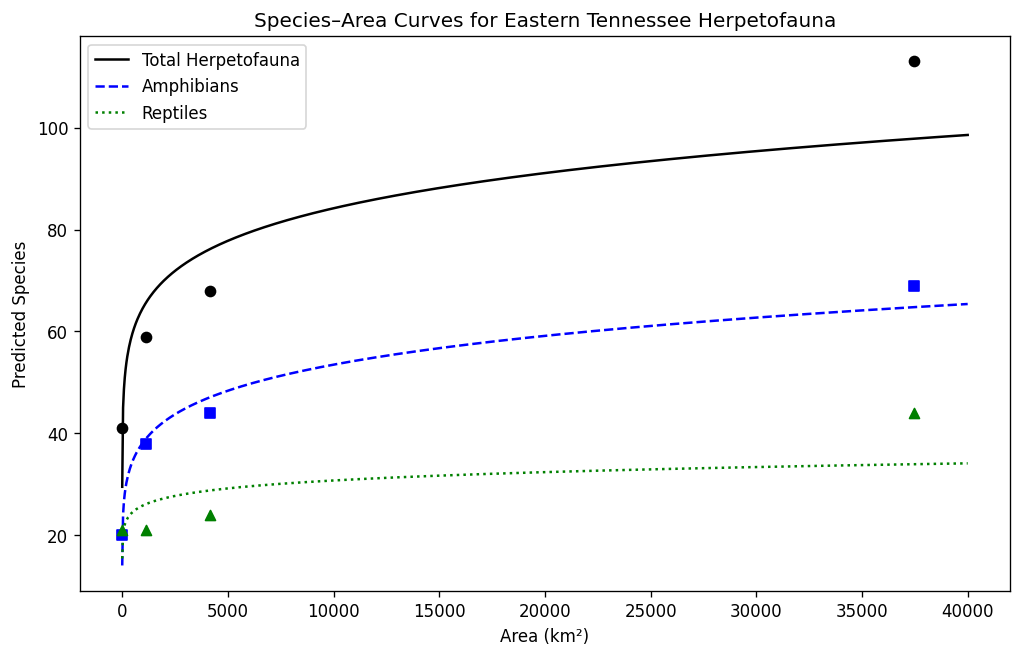

In [52]:
# Define predictive models using the calculated regression values
# C = 10^b (y-intercept) and z = m (slope)
def total_herpetofauna(area):
    return 10 ** b_herps * area ** m_herps

def amphibians(area):
    return 10 ** b_amphibians * area ** m_amphibians

def reptiles(area):
    return 10 ** b_reptiles * area ** m_reptiles

# create an array of areas from 1.0 to 40000.0
areas = np.linspace(1.0, 40000.0, num=1000, endpoint=True)

# vectorized predictions — no loop needed since the functions work element-wise
herp_species = total_herpetofauna(areas)
amphibian_species = amphibians(areas)
reptile_species = reptiles(areas)

# plot the data
plt.figure(figsize=(10, 6))
plt.plot(areas, herp_species, color='black', label='Total Herpetofauna')
plt.plot(areas, amphibian_species, color='blue', linestyle='--', label='Amphibians')
plt.plot(areas, reptile_species, color='green', linestyle=':', label='Reptiles')

# overlay observed data points
plt.scatter(df['Area'], df['TotalHerpetofauna'], color='black', zorder=5)
plt.scatter(df['Area'], df['Amphibians'], color='blue', marker='s', zorder=5)
plt.scatter(df['Area'], df['Reptiles'], color='green', marker='^', zorder=5)

plt.xlabel('Area (km²)')
plt.ylabel('Predicted Species')
plt.title('Species–Area Curves for Eastern Tennessee Herpetofauna')
plt.legend()
plt.show()

## Model Testing

Let's use the model to make predictions and compare with actual observations. The paper tested the model against sites like Great Smoky Mountains National Park (2114 km²) and Cumberland Gap National Park (82.74 km²).

In [53]:
# Test the model with known sites from the paper
# Great Smoky Mountains NP: 2114 km², reported 43 amphibians and 38 reptiles (81 total)
# Cumberland Gap NP: 82.74 km², reported 28 amphibians and 20 reptiles (48 total)

test_sites = {
    'Great Smoky Mountains NP': {'area': 2114, 'actual_amphibians': 43, 'actual_reptiles': 38},
    'Cumberland Gap NP': {'area': 82.74, 'actual_amphibians': 28, 'actual_reptiles': 20},
    'Steele Creek Park': {'area': 9.3, 'actual_amphibians': 20, 'actual_reptiles': 21}
}

rows = []
for site, data in test_sites.items():
    area = data['area']
    pred_a = amphibians(area)
    pred_r = reptiles(area)
    pred_t = total_herpetofauna(area)
    actual_t = data['actual_amphibians'] + data['actual_reptiles']
    rows.append({
        'Site': site,
        'Area (km²)': area,
        'Pred. Amphibians': round(pred_a, 1),
        'Actual Amphibians': data['actual_amphibians'],
        'Pred. Reptiles': round(pred_r, 1),
        'Actual Reptiles': data['actual_reptiles'],
        'Pred. Total': round(pred_t, 1),
        'Actual Total': actual_t,
        'Total % Error': round((pred_t - actual_t) / actual_t * 100, 1),
        'Amphibian % Error': round((pred_a - data['actual_amphibians']) / data['actual_amphibians'] * 100, 1),
        'Reptile % Error': round((pred_r - data['actual_reptiles']) / data['actual_reptiles'] * 100, 1),
    })

results = pd.DataFrame(rows).set_index('Site')
display(results)

,Area (km²),Pred. Amphibians,Actual Amphibians,Pred. Reptiles,Actual Reptiles,Pred. Total,Actual Total,Total % Error,Amphibian % Error,Reptile % Error
Site,,,,,,,,,,
Great Smoky Mountains NP,2114.00,42.7,43,27.4,38,70.5,81,-12.9,-0.7,-27.9
Cumberland Gap NP,82.74,26.7,28,21.5,20,48.8,48,1.6,-4.7,7.4
Steele Creek Park,9.30,19.4,20,18.2,21,38.0,41,-7.2,-2.8,-13.1


## Summary

The species–area relationship derived in this study provides evidence for predictability of amphibian and reptile richness per land area within temperate regions of similar geography in eastern Tennessee. Key findings include:

- **Total Herpetofauna:** The model explained 86% of the variation (Adj. R² = 0.86, P = 0.049)
- **Amphibians:** The strongest relationship, explaining 98% of variation (Adj. R² = 0.98, P = 0.006)
- **Reptiles:** Weaker relationship, explaining only 33% of variation (Adj. R² = 0.33, P = 0.257)

The amphibian model performed remarkably well when tested against Great Smoky Mountains National Park data, predicting 42.7 species compared to 43 reported. The weaker reptile relationship may be due to lower regional species richness compared to amphibians.

This newly estimated relationship has important implications for land use and conservation efforts and establishes a temporal regional baseline for herpetofaunal richness. As noted by the authors, amphibians and reptiles are ecological bellwethers, and understanding their biogeography at all scales will prove invaluable in an increasingly anthropogenically influenced, changing biosphere.